<a href="https://colab.research.google.com/github/ElBiologo/Business---analysis/blob/main/image_classifier_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import rasterio
from rasterio.windows import from_bounds

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
from rasterio.windows import Window

window = Window(1500, 1500, 1500, 1500)

In [3]:
archivos = [
    '/content/drive/MyDrive/geoData/bandas/banda_1.TIF',
    '/content/drive/MyDrive/geoData/bandas/banda_2.TIF',
    '/content/drive/MyDrive/geoData/bandas/banda_3.TIF',
    '/content/drive/MyDrive/geoData/bandas/banda_4.TIF',
    '/content/drive/MyDrive/geoData/bandas/banda_5.TIF',
    '/content/drive/MyDrive/geoData/bandas/banda_6.TIF',
    '/content/drive/MyDrive/geoData/bandas/banda_7.TIF'
]

In [4]:
bandas = []

for archivo in archivos:
    with rasterio.open(archivo) as src:
        bandas.append(src.read(1, window=window))

imagen = np.stack(bandas)

In [7]:
with rasterio.open('/content/drive/MyDrive/geoData/ESA_WorldCover_10m_2020_v100_S33W057_Map.tif') as src:
    cover = src.read(1, window=window)


In [8]:
X = imagen.reshape((imagen.shape[0], -1)).T
y = cover.reshape(-1)

In [7]:
X.shape

(2250000, 7)

In [9]:
mask = y != 0

X = X[mask]
y = y[mask]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [12]:
y_pred = modelo.predict(X_test)

In [13]:
y_pred.shape

(450000,)

In [14]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.9289711111111111

In [15]:
archivo_clasificar = [
    '/content/drive/MyDrive/geoData/bandas (2)/LC08_L2SP_223083_20230402_20230412_02_T1_SR_B1.TIF',
    '/content/drive/MyDrive/geoData/bandas (2)/LC08_L2SP_223083_20230402_20230412_02_T1_SR_B2.TIF',
    '/content/drive/MyDrive/geoData/bandas (2)/LC08_L2SP_223083_20230402_20230412_02_T1_SR_B3.TIF',
    '/content/drive/MyDrive/geoData/bandas (2)/LC08_L2SP_223083_20230402_20230412_02_T1_SR_B4.TIF',
    '/content/drive/MyDrive/geoData/bandas (2)/LC08_L2SP_223083_20230402_20230412_02_T1_SR_B5.TIF',
    '/content/drive/MyDrive/geoData/bandas (2)/LC08_L2SP_223083_20230402_20230412_02_T1_SR_B6.TIF',
    '/content/drive/MyDrive/geoData/bandas (2)/LC08_L2SP_223083_20230402_20230412_02_T1_SR_B7.TIF',
]

In [14]:
print(src.crs)

EPSG:4326


In [16]:
imagen_clasificar = []

for archivo in archivo_clasificar:
    with rasterio.open(archivo) as src:
        imagen_clasificar.append(src.read(1, window=window))

imagen_completa = np.stack(imagen_clasificar)

In [27]:
alto, ancho = imagen_completa.shape[1], imagen.shape[2]

X_clasificar = imagen_completa.reshape((imagen_completa.shape[0], -1)).T

In [29]:
predicciones = modelo.predict(X_clasificar)

In [32]:
predicciones.shape

(2250000,)

In [39]:
imagen_completa.shape

(7, 1500, 1500)

In [47]:
muestra1 = imagen_completa[1]

In [50]:
muestra1.shape

(1500, 1500)

In [51]:
muestra2.shape

(1500, 1500)

In [36]:
muestra2 = predicciones.reshape(alto, ancho)

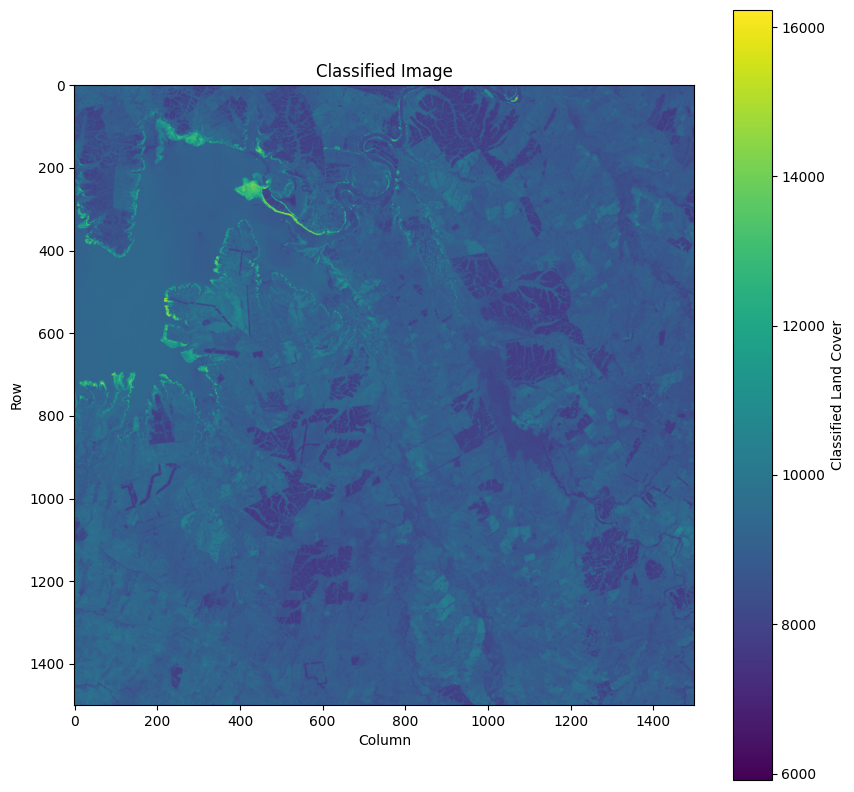

In [52]:
plt.figure(figsize=(10, 10))
plt.imshow(muestra1, cmap='viridis')
plt.colorbar(label='Classified Land Cover')
plt.title('Classified Image')
plt.xlabel('Column')
plt.ylabel('Row')
plt.show()

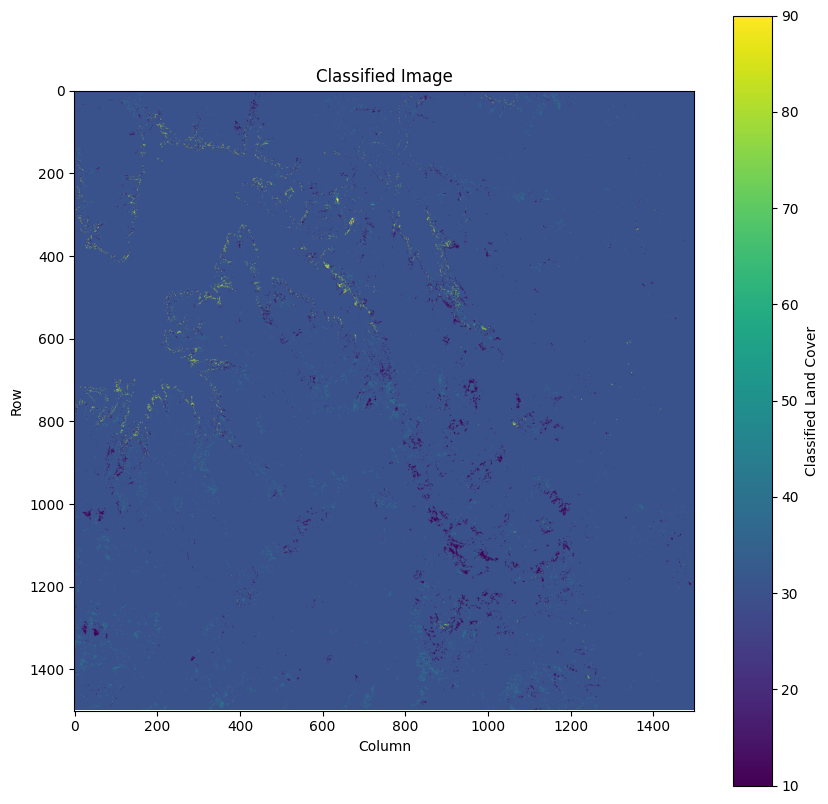

In [35]:
plt.figure(figsize=(10, 10))
plt.imshow(muestra1, cmap='viridis')
plt.colorbar(label='Classified Land Cover')
plt.title('Classified Image')
plt.xlabel('Column')
plt.ylabel('Row')
plt.show()